Notebook: Notebook 2 – Classification Modelling & Hyperparameter Tuning
Date: 10/03/2026



In [10]:
# To manipulate your data, load the following two libraries
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import tree
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

print("All libraries imported successfully.")

All libraries imported successfully.


In [12]:
# Load the classification dataset (output of Notebook 1)
df_loan_status = pd.read_csv('/content/loan_approval__data.csv')
df_loan_status.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


In [13]:
# The inputs are all the variables in the data assigned to X except the target, hence dropped
X = df_loan_status.drop(['loan_approval_status'], axis=1)

# The target output is assigned to y
y = df_loan_status['loan_approval_status']

# Check the list of input variables used for building classification models
print("Input feature names used for classification modelling:")
list(X)

Input feature names used for classification modelling:


['age',
 'income',
 'home_ownership',
 'emplyment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length']

In [14]:
# Check data shape function output
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (58645, 10)
y shape: (58645,)


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14, stratify=y)

# Show number of instances and input features in training and test sets
print('X_train Instances', X_train.shape)
print('X_test Instances', X_test.shape)
print()
print("Stratification verification:")
print(f"Train: Approved(0)={(y_train==0).sum()} Rejected(1)={(y_train==1).sum()}")
print(f"Test:  Approved(0)={(y_test==0).sum()}  Rejected(1)={(y_test==1).sum()}")

X_train Instances (46916, 10)
X_test Instances (11729, 10)

Stratification verification:
Train: Approved(0)=40236 Rejected(1)=6680
Test:  Approved(0)=10059  Rejected(1)=1670


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1_train = scaler.fit_transform(X_train)
X1_test = scaler.transform(X_test)

print("StandardScaler applied.")
print("X1_train shape:", X1_train.shape)
print("X1_test shape:", X1_test.shape)

StandardScaler applied.
X1_train shape: (46916, 10)
X1_test shape: (11729, 10)


In [17]:
# Import the Gaussian Naive Bayes module of Sklearn GaussianNB and create an instance
# Parametric algorithm — learns class priors and per-class Gaussian parameters (mean, variance)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X1_train, y_train)
y_pred_nb = nb.predict(X1_test)
print("Naive Bayes model fitted. Predictions made on test set.")

Naive Bayes model fitted. Predictions made on test set.


In [18]:
# Evaluate NB: Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10059
           1       0.49      0.62      0.55      1670

    accuracy                           0.86     11729
   macro avg       0.71      0.76      0.73     11729
weighted avg       0.87      0.86      0.86     11729



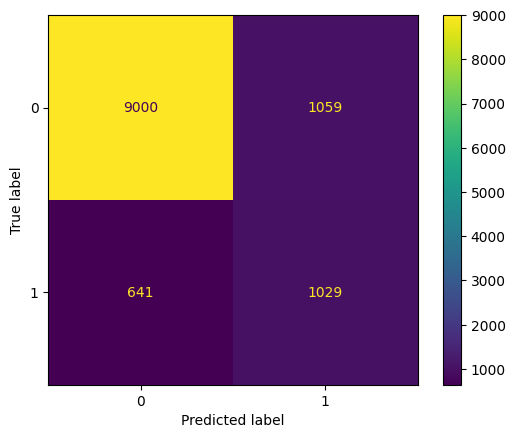

In [19]:
# Confusion matrix for NB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
nb_cm = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
nb_cm_display = ConfusionMatrixDisplay(nb_cm, display_labels=nb.classes_)
nb_cm_display.plot()

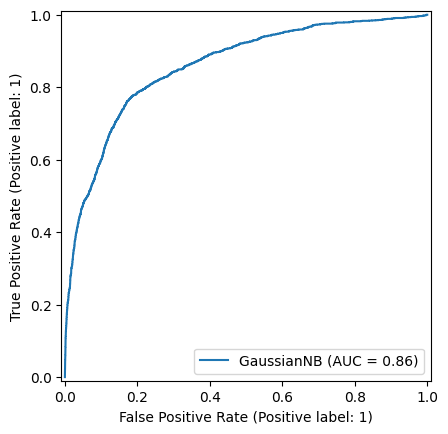

In [20]:
# ROC Curve for NB
from sklearn.metrics import RocCurveDisplay
nb_roc = RocCurveDisplay.from_estimator(nb, X1_test, y_test)

In [21]:
# import the class
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression()
logreg.fit(X1_train, y_train)
y_pred_lr = logreg.predict(X1_test)
print("Logistic Regression model fitted. Predictions made on test set.")

Logistic Regression model fitted. Predictions made on test set.


In [22]:
# The classification metrics report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10059
           1       0.73      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.82      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



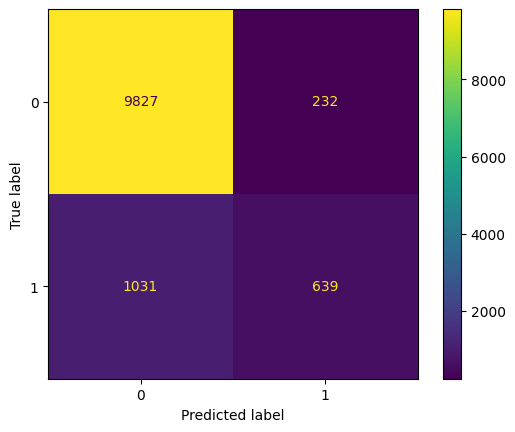

In [23]:
# Confusion matrix for LR
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
disp.plot()

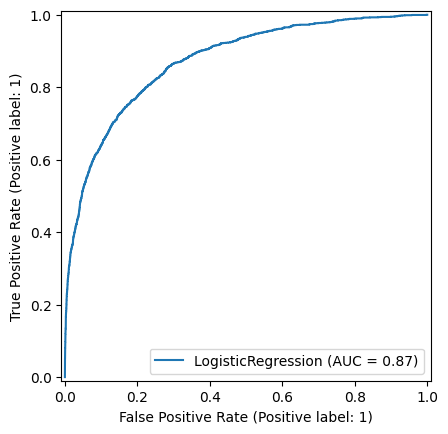

In [24]:
# Import the function from the package
from sklearn.metrics import RocCurveDisplay
# Apply the function by specifying the name of your model and test data.
Logreg_roc = RocCurveDisplay.from_estimator(logreg, X1_test, y_test)

In [25]:
# Create a KNN classifier
# Non-parametric algorithm — no explicit learnable parameters; memorises training data
from sklearn.neighbors import KNeighborsClassifier
# Create a KNN classifier
knn = KNeighborsClassifier(n_neighbors=9)
# Fit the classifier to the data
knn.fit(X_train, y_train)

# Perform predictions on the test data
y_pred_knn = knn.predict(X_test)
print("KNN (k=9) model fitted. Predictions made on test set.")

KNN (k=9) model fitted. Predictions made on test set.


In [26]:
# Classification report for KNN
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10059
           1       0.68      0.48      0.56      1670

    accuracy                           0.89     11729
   macro avg       0.80      0.72      0.75     11729
weighted avg       0.88      0.89      0.89     11729



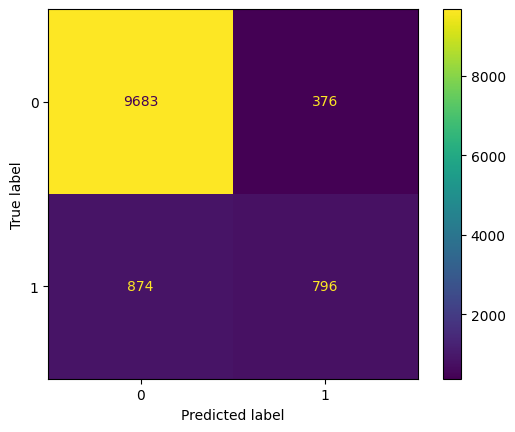

In [27]:
# Construct the confusion matrix based on comparing actual values (y_test) vs predicted (y_pred) in test data
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Import the packages for constructing the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
# Plot the confusion matrix
disp_knn_cm = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn_cm.plot()

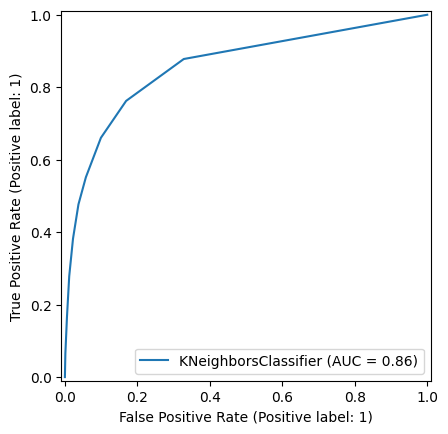

In [28]:
from sklearn.metrics import RocCurveDisplay
knn_roc = RocCurveDisplay.from_estimator(knn, X_test, y_test)

Optimal K (lowest error rate): 8


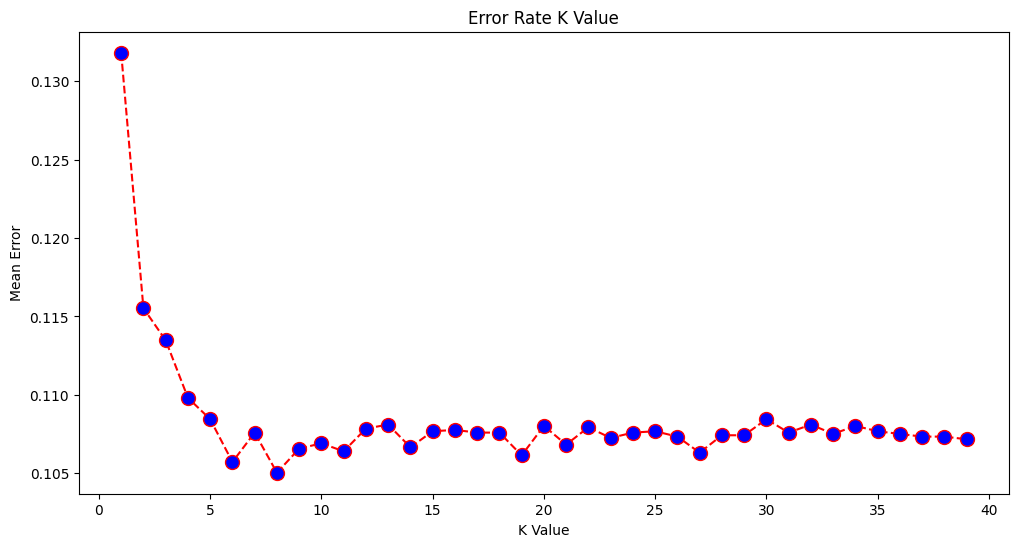

In [29]:
# Calculating error for K values between 1 and 40
error = []
import numpy as np
import matplotlib.pyplot as plt
# Calculating error for K values between 1 and 40
for i in range(1, 40):
    knn2 = KNeighborsClassifier(n_neighbors=i)
    knn2.fit(X_train, y_train)
    pred_i = knn2.predict(X_test)
    error.append(np.mean(pred_i != y_test))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
print("Optimal K (lowest error rate):", (range(1, 40))[np.argmin(error)])

In [30]:
# Import the function to calculate accuracy score
from sklearn.metrics import accuracy_score

# NB accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print('Naive Bayes (NB) Accuracy:', accuracy_nb)

# LR accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression (LR) Accuracy:', accuracy_lr)

# KNN accuracy (k=9)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print('KNN (k=9) Accuracy:', accuracy_knn)

Naive Bayes (NB) Accuracy: 0.855060107426038
Logistic Regression (LR) Accuracy: 0.89231818569358
KNN (k=9) Accuracy: 0.8934265495779692


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

print("Performance Metrics Summary — Rejected class (1) = class of interest per success criteria")
print("-" * 75)
for name, yp, yprob_model in [
    ("NB",  y_pred_nb,  nb.predict_proba(X1_test)[:,1]),
    ("LR",  y_pred_lr,  logreg.predict_proba(X1_test)[:,1]),
    ("KNN", y_pred_knn, knn.predict_proba(X_test)[:,1]),
]:
    acc  = round(accuracy_score(y_test, yp), 4)
    rec  = round(recall_score(y_test, yp, pos_label=1), 4)
    prec = round(precision_score(y_test, yp, pos_label=1), 4)
    f1   = round(f1_score(y_test, yp, pos_label=1), 4)
    auc  = round(roc_auc_score(y_test, yprob_model), 4)
    print(f"{name:>6}: Accuracy={acc}  Recall(1)={rec}  Precision(1)={prec}  F1(1)={f1}  AUC-ROC={auc}")

Performance Metrics Summary — Rejected class (1) = class of interest per success criteria
---------------------------------------------------------------------------
    NB: Accuracy=0.8551  Recall(1)=0.6162  Precision(1)=0.4928  F1(1)=0.5476  AUC-ROC=0.8586
    LR: Accuracy=0.8923  Recall(1)=0.3826  Precision(1)=0.7336  F1(1)=0.503  AUC-ROC=0.8726
   KNN: Accuracy=0.8934  Recall(1)=0.4766  Precision(1)=0.6792  F1(1)=0.5602  AUC-ROC=0.8584


In [32]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Create new NB model
from sklearn.naive_bayes import GaussianNB
nb_optimise = GaussianNB()

# Create a dictionary of all values we want to test for var_smoothing
param_grid = {'var_smoothing': np.logspace(-12, 0, 20)}

# Use gridsearch to test all values for var_smoothing
# scoring='recall' — optimise for Recall per success criteria (detect as many rejections as possible)
knn_gscv = GridSearchCV(nb_optimise, param_grid, cv=5, scoring='recall')

# Fit model to data
knn_gscv.fit(X1_train, y_train)

# Check top performing var_smoothing value
knn_gscv.best_params_

{'var_smoothing': np.float64(1e-12)}

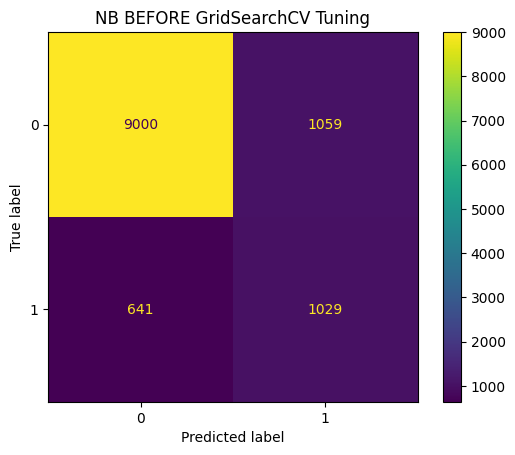

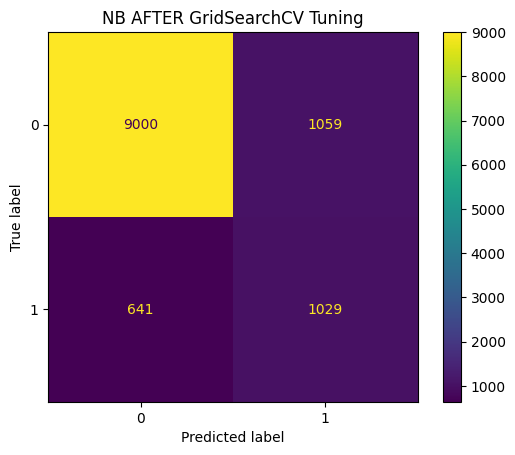

In [33]:
# Perform testing on test dataset with the tuned model
y_pred_nb_tuned = knn_gscv.predict(X1_test)

# Construct a confusion matrix before and after tuning
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# BEFORE tuning (original NB)
cm_nb_before = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
disp_before = ConfusionMatrixDisplay(cm_nb_before, display_labels=nb.classes_)
disp_before.plot()
plt.title("NB BEFORE GridSearchCV Tuning")
plt.show()

# AFTER tuning
cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned, labels=knn_gscv.classes_)
disp_after = ConfusionMatrixDisplay(cm_nb_tuned, display_labels=knn_gscv.classes_)
disp_after.plot()
plt.title("NB AFTER GridSearchCV Tuning")
plt.show()

In [34]:
print("NB AFTER GridSearchCV Tuning — Classification Report:")
print(classification_report(y_test, y_pred_nb_tuned))

# Performance comparison
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
print("Performance Comparison — Before vs After Tuning (NB):")
print(f"{'Metric':<20} {'Before':>12} {'After':>12}")
print("-" * 50)
for metric_name, func in [("Accuracy", accuracy_score),
    ("Recall(1)", lambda yt,yp: recall_score(yt,yp,pos_label=1)),
    ("Precision(1)", lambda yt,yp: precision_score(yt,yp,pos_label=1)),
    ("F1(1)", lambda yt,yp: f1_score(yt,yp,pos_label=1))]:
    b = round(func(y_test, y_pred_nb), 4)
    a = round(func(y_test, y_pred_nb_tuned), 4)
    print(f"  {metric_name:<18} {b:>12} {a:>12}")

NB AFTER GridSearchCV Tuning — Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10059
           1       0.49      0.62      0.55      1670

    accuracy                           0.86     11729
   macro avg       0.71      0.76      0.73     11729
weighted avg       0.87      0.86      0.86     11729

Performance Comparison — Before vs After Tuning (NB):
Metric                     Before        After
--------------------------------------------------
  Accuracy                 0.8551       0.8551
  Recall(1)                0.6162       0.6162
  Precision(1)             0.4928       0.4928
  F1(1)                    0.5476       0.5476
